In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2025-01-15 17:33:01**

In [ ]:
# Importing the necessary libraries
import pandas as pd  # Pandas for data manipulation and analysis
import matplotlib.pyplot as plt  # Matplotlib for data visualization, including plotting charts
from sklearn.linear_model import LinearRegression  # Linear Regression model for machine learning
import pickle  # Pickle for serializing and deserializing Python objects, used for saving/loading machine learning models

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [ ]:
# Reading a CSV file from a URL and creating a DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/9394113857/Data-Sets/a7ba0b540a02e3a0e06564365c9fd8730a60d382/house_price.csv')

In [ ]:
df

,Area,Price
0,1000,1500000
1,1200,1800000
2,1500,2250000
3,1800,2700000
4,2000,3000000
5,2300,3450000
6,2500,3750000
7,2700,4050000
8,3000,4500000
9,3200,4800000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    10 non-null     int64
 1   Price   10 non-null     int64
dtypes: int64(2)
memory usage: 288.0 bytes


In [ ]:
df.shape

(10, 2)

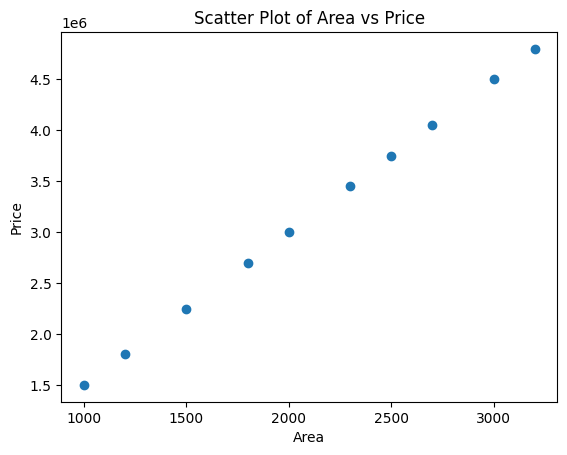

In [ ]:
# Creating a scatter plot to visualize the relationship between 'Area' and 'Price'
plt.scatter(df['Area'], df['Price'])
plt.xlabel('Area')  # Adding label to the x-axis
plt.ylabel('Price')  # Adding label to the y-axis
plt.title('Scatter Plot of Area vs Price')  # Adding a title to the plot
plt.show()  # Displaying the plot

In [ ]:
# Extracting the 'Area' column values and reshaping it into a 2D array with a single column
# The -1 in the reshape function is a placeholder that automatically calculates the size of the other dimension,
# ensuring that the resulting array has the same number of elements as the original
x = df['Area'].values.reshape(-1, 1)

# Extracting the 'Price' column values and reshaping it into a 2D array with a single column
y = df['Price'].values.reshape(-1, 1)

In [ ]:
from sklearn.model_selection import train_test_split
# Split data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42) # Adjust test_size and random_state as needed

In [ ]:
# Create a Linear Regression model instance
model = LinearRegression()

In [ ]:
# Fit the model using feature 'x' and target 'y' data
model = Ridge(alpha=1.0)
model.fit(x_train, y_train)



Ridge()

In [ ]:
# Make predictions on the training and validation sets
train_predictions = model.predict(x_train)
val_predictions = model.predict(x_val)

In [ ]:
print("Train RMSE:", mean_squared_error(y_train, train_predictions)**0.5) # Calculate RMSE manually
print("Validation RMSE:", mean_squared_error(y_val, val_predictions)**0.5) # Calculate RMSE manually

Train RMSE: 0.28614276427300256
Validation RMSE: 0.3931645821853428


**If the model still overfits, increase the alpha value.**

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(model, x, y, cv=5, scoring='neg_mean_squared_error')


In [ ]:
# NameError: name 'scores' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score

# Assuming 'x' and 'y' are already defined with your feature and target data
# x = df['Area'].values.reshape(-1, 1)
# y = df['Price'].values.reshape(-1, 1)

# Calculate cross-validation scores using your existing 'x' and 'y'
scores = cross_val_score(model, x, y, cv=5, scoring='neg_mean_squared_error')

# Now you can print the scores:
print("Cross-Validation RMSE per fold:", (-scores)**0.5)
print("Mean CV RMSE:", (-scores.mean())**0.5)

Cross-Validation RMSE per fold: [0.78783267 0.20398537 0.0463039  0.20457717 0.69966284]
Mean CV RMSE: 0.48904280019572827


**If performance is inconsistent, consider stratified sampling or revisiting feature engineering.**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
selector = SelectKBest(score_func=f_regression, k=5)
X_train_reduced = selector.fit_transform(x_train, y_train)
X_val_reduced = selector.transform(x_val)  # Changed X_val to x_val

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:779: UserWarning: k=5 is greater than n_features=1. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Train with reduced features
model = Ridge(alpha=1.0)
model.fit(X_train_reduced, y_train)

Ridge()

In [ ]:
# Evaluate on reduced data
train_predictions = model.predict(X_train_reduced)
val_predictions = model.predict(X_val_reduced)

In [ ]:
selector = SelectKBest(score_func=f_regression, k=5)
X_train_reduced = selector.fit_transform(x_train, y_train)
X_val_reduced = selector.transform(x_val)  # Changed X_val to x_val

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:779: UserWarning: k=5 is greater than n_features=1. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**If accuracy drops significantly, you may need to adjust the number of features (k) or refine feature selection methods.**

In [ ]:
from rich.console import Console
import time  # Import the time module to check execution time
from datetime import datetime  # Import datetime module for current date and time
import warnings
import sys

# Suppress the specific warning related to feature names
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

# Record the start time
start_time = time.time()

# Get the current date and time at the start
start_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")  # Format: Year-Month-Day Hour:Minute:Second

# Create a Console instance for rich text printing
console = Console()

# Print the start date and time
console.print(f"[bold cyan]Execution Started at: {start_datetime}[/bold cyan]")

# Show the current date and time right before asking for the user input
current_datetime_before_input = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time before input: {current_datetime_before_input}[/bold cyan]")

# Get user input for area with a colorized prompt
console.print("[bold cyan]Please Enter Area in Sq ft (Press Enter for default 900 sq ft):[/bold cyan]", end=" ")

area_input = input()

# Check if the user input is empty (i.e., they just pressed Enter)
if area_input == "":
    area = 900  # Use 900 sq ft as the default value if no input is provided
    console.print("[bold yellow]No area entered, using default: 900 sq ft[/bold yellow]")
else:
    # If the user provided an area, convert it to a float
    try:
        area = float(area_input)
        console.print(f"[bold green]User entered area: {area} sq ft[/bold green]")
    except ValueError:
        console.print("[bold red]Invalid input! Please enter a valid number for area.[/bold red]")
        exit()

# Live update feature: Update the current time in real-time as the program runs
for _ in range(5):  # Loop for 5 seconds, update the current time every second
    time.sleep(1)  # Delay for 1 second
    live_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    console.print(f"[bold cyan]Live current time: {live_time}[/bold cyan]", end="\r")
    sys.stdout.flush()  # This ensures the line gets updated, not appended

# Use the model to predict based on the entered or defaulted area
prediction_value = model.predict([[area]])

# Extract the predicted price from the array (it should be a single value) using .item()
predicted_price = prediction_value[0].item()  # Using .item() to convert the NumPy array to a scalar

# Print the entered or defaulted area in bold magenta
console.print(f"[bold magenta]The entered area: {area} Sq ft[/bold magenta]")

# Print the predicted value from the model in bold blue, formatted properly
console.print(f"[bold blue]The Price Amount is: {predicted_price:,.2f} Rupees[/bold blue]")

# Record the end time and calculate the total time taken
end_time = time.time()
execution_time = end_time - start_time  # Calculate the time difference

# Get the current date and time at the end
end_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Print the end date and time
console.print(f"[bold cyan]Execution Finished at: {end_datetime}[/bold cyan]")

# Print the time taken for execution
console.print(f"[bold magenta]Time taken for execution: {execution_time:.2f} seconds[/bold magenta]")

# Print section separators
console.print("[bold yellow]======================================[/bold yellow]")
console.print("[bold yellow]======================================[/bold yellow]")

# Show the current date and time after the execution is completed
current_datetime_after_execution = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time after execution: {current_datetime_after_execution}[/bold cyan]")


Execution Started at: 2025-01-15 12:12:44

Current Date and Time before input: 2025-01-15 12:12:44

Please Enter Area in Sq ft (Press Enter for default 900 sq ft):

900


User entered area: 900.0 sq ft

...

Execution Finished at: 2025-01-15 12:12:53

Time taken for execution: 8.50 seconds

======================================

======================================

Current Date and Time after execution: 2025-01-15 12:12:53

In [ ]:
##############

In [ ]:
# Save the trained Linear Regression model using Pickle
import pickle

In [ ]:
# Specify the filename ('house_price_linear_regression.pkl') and open in binary write mode ('wb')
pickle.dump(model, open('house_price_linear_regression.pkl', 'wb'))

In [ ]:
# Specify the filename ('house_price_linear_regression.pkl') and open in binary read mode ('rb')
loaded_linear_regression_model = pickle.load(open("house_price_linear_regression.pkl", "rb"))

In [ ]:
import pickle
from rich.console import Console
import time  # Import the time module to check execution time
from datetime import datetime  # Import datetime module for current date and time
import warnings
import sys

# Suppress the specific warning related to feature names
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

# Record the start time
start_time = time.time()

# Get the current date and time at the start
start_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")  # Format: Year-Month-Day Hour:Minute:Second

# Load the pre-trained linear regression model
loaded_linear_regression_model = pickle.load(open('house_price_linear_regression.pkl', 'rb'))  # Replace with the actual path to your model file

# Create a Console instance for rich text printing
console = Console()

# Print the start date and time
console.print(f"[bold cyan]Execution Started at: {start_datetime}[/bold cyan]")

# Show the current date and time right before asking for the user input
current_datetime_before_input = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time before input: {current_datetime_before_input}[/bold cyan]")

# Get user input for area with a colorized prompt
console.print("[bold cyan]Please Enter Area in Sq ft (Press Enter for default 900 sq ft):[/bold cyan]", end=" ")

area_input = input()

# Check if the user input is empty (i.e., they just pressed Enter)
if area_input == "":
    area = 900  # Use 900 sq ft as the default value if no input is provided
    console.print("[bold yellow]No area entered, using default: 900 sq ft[/bold yellow]")
else:
    # If the user provided an area, convert it to a float
    try:
        area = float(area_input)
        console.print(f"[bold green]User entered area: {area} sq ft[/bold green]")
    except ValueError:
        console.print("[bold red]Invalid input! Please enter a valid number for area.[/bold red]")
        exit()

# Live update feature: Update the current time in real-time as the program runs
for _ in range(5):  # Loop for 5 seconds, update the current time every second
    time.sleep(1)  # Delay for 1 second
    live_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    console.print(f"[bold cyan]Live current time: {live_time}[/bold cyan]", end="\r")
    sys.stdout.flush()  # This ensures the line gets updated, not appended

# Use the model to predict based on the entered or defaulted area
prediction_value = loaded_linear_regression_model.predict([[area]])

# Extract the predicted price from the array (it should be a single value) using .item()
predicted_price = prediction_value[0].item()  # Using .item() to convert the NumPy array to a scalar

# Print the entered or defaulted area in bold magenta
console.print(f"[bold magenta]The entered area: {area} Sq ft[/bold magenta]")

# Print the predicted value from the model in bold blue, formatted properly
console.print(f"[bold blue]The Price Amount is: {predicted_price:,.2f} Rupees[/bold blue]")

# Record the end time and calculate the total time taken
end_time = time.time()
execution_time = end_time - start_time  # Calculate the time difference

# Get the current date and time at the end
end_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Print the end date and time
console.print(f"[bold cyan]Execution Finished at: {end_datetime}[/bold cyan]")

# Print the time taken for execution
console.print(f"[bold magenta]Time taken for execution: {execution_time:.2f} seconds[/bold magenta]")

# Print section separators
console.print("[bold yellow]======================================[/bold yellow]")
console.print("[bold yellow]======================================[/bold yellow]")

# Show the current date and time after the execution is completed
current_datetime_after_execution = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
console.print(f"[bold cyan]Current Date and Time after execution: {current_datetime_after_execution}[/bold cyan]")


Execution Started at: 2025-01-15 11:46:41

Current Date and Time before input: 2025-01-15 11:46:41

Please Enter Area in Sq ft (Press Enter for default 900 sq ft):

900


User entered area: 900.0 sq ft

...

Execution Finished at: 2025-01-15 11:46:49

Time taken for execution: 8.71 seconds

======================================

======================================

Current Date and Time after execution: 2025-01-15 11:46:49

In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2025-01-15 17:16:49 IST+0530**

In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2025-01-15 17:16:10**

**Last Cell Entry Time: 2025-01-15 17:16:49 IST+0530**

**Time Taken: 0 hour(s), 0 minute(s), and 39 second(s)**